#### SECTION 1: SETUP AND IMPORTS


In [4]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                            roc_curve, auc, precision_recall_curve)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Configure plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


#### SECTION 2 : UNZIP AND SETUP DATASET


In [5]:
print("EXTRACTING DATASET")

# Unzip the dataset
zip_path = '/content/resized_224.zip'  # Update this path if needed
extract_path = '/content/dataset'

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f" Dataset extracted to {extract_path}")
else:
    print(f" Zip file not found at {zip_path}")
    print("Please upload resized_224.zip to Colab")

# Define paths
base_dir = os.path.join(extract_path, 'resized_224')
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

# Verify dataset structure
for split_name, split_dir in [('Train', train_dir), ('Validation', val_dir), ('Test', test_dir)]:
    if os.path.exists(split_dir):
        cardio_count = len(os.listdir(os.path.join(split_dir, 'Cardiomegaly')))
        normal_count = len(os.listdir(os.path.join(split_dir, 'No Finding')))
        print(f"{split_name:12} - Cardiomegaly: {cardio_count:4d} | No Finding: {normal_count:4d}")

EXTRACTING DATASET
 Dataset extracted to /content/dataset
Train        - Cardiomegaly:  800 | No Finding:  800
Validation   - Cardiomegaly:  192 | No Finding:  192
Test         - Cardiomegaly:  100 | No Finding:  100


#### SECTION 3: DATA PREPARATION


In [6]:
print("DATA PREPARATION")

# Hyperparameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 0.001

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.15,
    fill_mode='nearest'
)

# Only rescaling for validation and test
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    seed=42
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(f"\n Data generators created successfully")
print(f"  Class indices: {train_generator.class_indices}")

DATA PREPARATION
Found 1600 images belonging to 2 classes.
Found 384 images belonging to 2 classes.
Found 200 images belonging to 2 classes.

 Data generators created successfully
  Class indices: {'Cardiomegaly': 0, 'No Finding': 1}


#### SECTION 4: BASELINE CNN MODEL


In [7]:
print("BASELINE CNN MODEL")

def create_baseline_cnn():
    """Create a baseline CNN architecture"""
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        # Block 4
        layers.Conv2D(256, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        # Dense layers
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])

    return model

# Create and compile baseline model
baseline_model = create_baseline_cnn()
baseline_model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(),
             tf.keras.metrics.Recall(), tf.keras.metrics.AUC()]
)

print("\n Baseline CNN Architecture:")
baseline_model.summary()

# Callbacks
baseline_callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    ModelCheckpoint('baseline_best.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]

# Train baseline model
print("\n Training Baseline CNN...")
baseline_history = baseline_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=baseline_callbacks,
    verbose=1
)

BASELINE CNN MODEL

 Baseline CNN Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 19,399,873 (74.00 MB)

 Trainable params: 19,397,377 (74.00 MB)

...

50/50 ━━━━━━━━━━━━━━━━━━━━ 41s 481ms/step - accuracy: 0.5510 - auc: 0.5610 - loss: 0.9898 - precision: 0.5402 - recall: 0.5530 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 3.6207 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.5455 - auc: 0.5413 - loss: 0.9234 - precision: 0.5429 - recall: 0.5466
Epoch 2: val_accuracy did not improve from 0.50000
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 418ms/step - accuracy: 0.5452 - auc: 0.5411 - loss: 0.9234 - precision: 0.5426 - recall: 0.5460 - val_accuracy: 0.5000 - val_auc: 0.5912 - val_loss: 1.7545 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.5787 - auc: 0.5851 - loss: 0.8303 - precision: 0.5926 - recall: 0.5572
Epoch 3: val_accuracy did not improve from 0.50000
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 399ms/step - accuracy: 0.5785 - auc: 0.5850 - loss: 0.8303 - precision: 0.5922 - 

50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 410ms/step - accuracy: 0.5713 - auc: 0.5887 - loss: 0.7451 - precision: 0.5757 - recall: 0.5491 - val_accuracy: 0.5729 - val_auc: 0.5761 - val_loss: 0.8023 - val_precision: 0.5854 - val_recall: 0.5000 - learning_rate: 0.0010
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.5815 - auc: 0.5978 - loss: 0.7425 - precision: 0.5574 - recall: 0.5811
Epoch 8: val_accuracy improved from 0.57292 to 0.57812, saving model to baseline_best.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 428ms/step - accuracy: 0.5817 - auc: 0.5979 - loss: 0.7424 - precision: 0.5581 - recall: 0.5814 - val_accuracy: 0.5781 - val_auc: 0.5738 - val_loss: 0.7359 - val_precision: 0.5591 - val_recall: 0.7396 - learning_rate: 0.0010
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.5754 - auc: 0.6085 - loss: 0.7270 - precision: 0.5716 - recall: 0.5490
Epoch 9: val_accuracy did not improve from 0.57812
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 424ms/step - accuracy: 0.5754 - auc: 0.6083 - loss: 0.7272 - precision: 0.5717 - recall: 0.5493 - val_accuracy: 0.5651 - val_auc: 0.5336 - val_loss: 0.7152 - val_precision: 0.5546 - val_recall: 0.6615 - learning_rate: 0.0010
Epoch 10/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.5773 - auc: 0.6149 - loss: 0.6949 - precision: 0.5595 - recall: 0.5586
Epoch 10: val_accuracy did not improve from 0.57812
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 405ms/step - accuracy: 0.5775 - auc: 0.6151 - loss: 0.6948 - precision: 0.5601 

50/50 ━━━━━━━━━━━━━━━━━━━━ 25s 481ms/step - accuracy: 0.6093 - auc: 0.6501 - loss: 0.6631 - precision: 0.6137 - recall: 0.6016 - val_accuracy: 0.5833 - val_auc: 0.6797 - val_loss: 0.6674 - val_precision: 0.5537 - val_recall: 0.8594 - learning_rate: 5.0000e-04
Epoch 19/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 586ms/step - accuracy: 0.6167 - auc: 0.6449 - loss: 0.6664 - precision: 0.6005 - recall: 0.6040
Epoch 19: val_accuracy did not improve from 0.58333
50/50 ━━━━━━━━━━━━━━━━━━━━ 30s 600ms/step - accuracy: 0.6166 - auc: 0.6452 - loss: 0.6662 - precision: 0.6008 - recall: 0.6038 - val_accuracy: 0.5391 - val_auc: 0.5731 - val_loss: 1.3353 - val_precision: 0.5221 - val_recall: 0.9219 - learning_rate: 5.0000e-04
Epoch 20/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.5919 - auc: 0.6315 - loss: 0.6693 - precision: 0.6371 - recall: 0.5481
Epoch 20: val_accuracy did not improve from 0.58333
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 459ms/step - accuracy: 0.5921 - auc: 0.6318 - loss: 0.6691 - precisio

50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 433ms/step - accuracy: 0.6029 - auc: 0.6562 - loss: 0.6555 - precision: 0.5851 - recall: 0.5780 - val_accuracy: 0.6328 - val_auc: 0.6638 - val_loss: 0.6555 - val_precision: 0.6269 - val_recall: 0.6562 - learning_rate: 5.0000e-04
Epoch 24/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.6121 - auc: 0.6535 - loss: 0.6568 - precision: 0.6010 - recall: 0.5862
Epoch 24: val_accuracy did not improve from 0.63281
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 425ms/step - accuracy: 0.6123 - auc: 0.6538 - loss: 0.6566 - precision: 0.6016 - recall: 0.5864 - val_accuracy: 0.5729 - val_auc: 0.6932 - val_loss: 0.6787 - val_precision: 0.5443 - val_recall: 0.8958 - learning_rate: 5.0000e-04
Epoch 25/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.6370 - auc: 0.6859 - loss: 0.6411 - precision: 0.6257 - recall: 0.6511
Epoch 25: val_accuracy did not improve from 0.63281
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 397ms/step - accuracy: 0.6367 - auc: 0.6855 - loss: 0.6413 - precisio

#### SECTION 5: DENSENET121 MODEL


In [8]:
print("DENSENET121 MODEL WITH TRANSFER LEARNING")

def create_densenet121_model():
    """Create DenseNet121 model with transfer learning"""
    # Load pre-trained DenseNet121
    base_model = DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )

    # Freeze initial layers
    for layer in base_model.layers[:-30]:
        layer.trainable = False

    # Add custom classification head
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.BatchNormalization(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(1, activation='sigmoid')
    ])

    return model

# Create and compile DenseNet121 model
densenet_model = create_densenet121_model()
densenet_model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(),
             tf.keras.metrics.Recall(), tf.keras.metrics.AUC()]
)

print("\n DenseNet121 Architecture:")
densenet_model.summary()

# Callbacks
densenet_callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    ModelCheckpoint('densenet_best.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]

# Train DenseNet121 model
print("\n Training DenseNet121...")
densenet_history = densenet_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=densenet_callbacks,
    verbose=1
)


DENSENET121 MODEL WITH TRANSFER LEARNING
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

 DenseNet121 Architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,700,033 (29.37 MB)

 Trainable params: 1,300,865 (4.96 MB)

...

50/50 ━━━━━━━━━━━━━━━━━━━━ 73s 702ms/step - accuracy: 0.5487 - auc_1: 0.5769 - loss: 0.8512 - precision_1: 0.5355 - recall_1: 0.5033 - val_accuracy: 0.5859 - val_auc_1: 0.6931 - val_loss: 0.7458 - val_precision_1: 0.5587 - val_recall_1: 0.8177 - learning_rate: 0.0010
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.6541 - auc_1: 0.7085 - loss: 0.7053 - precision_1: 0.6485 - recall_1: 0.6359
Epoch 2: val_accuracy did not improve from 0.58594
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 424ms/step - accuracy: 0.6543 - auc_1: 0.7088 - loss: 0.7051 - precision_1: 0.6488 - recall_1: 0.6366 - val_accuracy: 0.5677 - val_auc_1: 0.7955 - val_loss: 0.8143 - val_precision_1: 0.8250 - val_recall_1: 0.1719 - learning_rate: 0.0010
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.6931 - auc_1: 0.7629 - loss: 0.6380 - precision_1: 0.7068 - recall_1: 0.6693
Epoch 3: val_accuracy improved from 0.58594 to 0.75521, saving model to densenet_best.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 424ms/step - accuracy: 0.6928 - auc_1: 0.7628 - loss: 0.6381 - precision_1: 0.7063 - recall_1: 0.6694 - val_accuracy: 0.7552 - val_auc_1: 0.8181 - val_loss: 0.5319 - val_precision_1: 0.7849 - val_recall_1: 0.7031 - learning_rate: 0.0010
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.7245 - auc_1: 0.8106 - loss: 0.5617 - precision_1: 0.7319 - recall_1: 0.7028
Epoch 4: val_accuracy did not improve from 0.75521
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 420ms/step - accuracy: 0.7245 - auc_1: 0.8104 - loss: 0.5619 - precision_1: 0.7319 - recall_1: 0.7029 - val_accuracy: 0.7318 - val_auc_1: 0.8557 - val_loss: 0.5474 - val_precision_1: 0.8450 - val_recall_1: 0.5677 - learning_rate: 0.0010
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.7492 - auc_1: 0.8331 - loss: 0.5290 - precision_1: 0.7381 - recall_1: 0.7676
Epoch 5: val_accuracy did not improve from 0.75521
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 425ms/step - accuracy: 0.7492 - auc_1: 0.8331

50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 440ms/step - accuracy: 0.7921 - auc_1: 0.8695 - loss: 0.4666 - precision_1: 0.7704 - recall_1: 0.8156 - val_accuracy: 0.7786 - val_auc_1: 0.8706 - val_loss: 0.5091 - val_precision_1: 0.8323 - val_recall_1: 0.6979 - learning_rate: 5.0000e-04
Epoch 10/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.8259 - auc_1: 0.9040 - loss: 0.3989 - precision_1: 0.8159 - recall_1: 0.8477
Epoch 10: val_accuracy did not improve from 0.77865
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 414ms/step - accuracy: 0.8257 - auc_1: 0.9039 - loss: 0.3991 - precision_1: 0.8156 - recall_1: 0.8474 - val_accuracy: 0.7656 - val_auc_1: 0.8335 - val_loss: 0.6721 - val_precision_1: 0.8542 - val_recall_1: 0.6406 - learning_rate: 5.0000e-04
Epoch 11/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.8205 - auc_1: 0.8981 - loss: 0.4103 - precision_1: 0.8288 - recall_1: 0.8054
Epoch 11: val_accuracy did not improve from 0.77865
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 415ms/step - accuracy: 0.8205 - a

50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 437ms/step - accuracy: 0.8325 - auc_1: 0.9254 - loss: 0.3481 - precision_1: 0.8306 - recall_1: 0.8308 - val_accuracy: 0.7917 - val_auc_1: 0.8712 - val_loss: 0.5173 - val_precision_1: 0.7593 - val_recall_1: 0.8542 - learning_rate: 5.0000e-04
Epoch 17/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.8559 - auc_1: 0.9314 - loss: 0.3371 - precision_1: 0.8460 - recall_1: 0.8579
Epoch 17: val_accuracy did not improve from 0.79167
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 424ms/step - accuracy: 0.8560 - auc_1: 0.9314 - loss: 0.3369 - precision_1: 0.8463 - recall_1: 0.8578 - val_accuracy: 0.7682 - val_auc_1: 0.8679 - val_loss: 0.5229 - val_precision_1: 0.7330 - val_recall_1: 0.8438 - learning_rate: 2.5000e-04
Epoch 18/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.8809 - auc_1: 0.9429 - loss: 0.3065 - precision_1: 0.8831 - recall_1: 0.8824
Epoch 18: val_accuracy did not improve from 0.79167
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 404ms/step - accuracy: 0.8807 - a

50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 429ms/step - accuracy: 0.8883 - auc_1: 0.9551 - loss: 0.2713 - precision_1: 0.8823 - recall_1: 0.8949 - val_accuracy: 0.7943 - val_auc_1: 0.8781 - val_loss: 0.4745 - val_precision_1: 0.7897 - val_recall_1: 0.8021 - learning_rate: 2.5000e-04
Epoch 22/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.8700 - auc_1: 0.9520 - loss: 0.2833 - precision_1: 0.8579 - recall_1: 0.8808
Epoch 22: val_accuracy did not improve from 0.79427
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 406ms/step - accuracy: 0.8698 - auc_1: 0.9518 - loss: 0.2837 - precision_1: 0.8581 - recall_1: 0.8803 - val_accuracy: 0.7865 - val_auc_1: 0.8713 - val_loss: 0.5269 - val_precision_1: 0.8395 - val_recall_1: 0.7083 - learning_rate: 2.5000e-04
Epoch 23/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.8864 - auc_1: 0.9594 - loss: 0.2643 - precision_1: 0.8753 - recall_1: 0.8932
Epoch 23: val_accuracy did not improve from 0.79427
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 428ms/step - accuracy: 0.8865 - a

#### SECTION 6: EVALUATION AND VISUALIZATION


In [16]:
print("MODEL EVALUATION")

def evaluate_model(model, generator, model_name):
    """Comprehensive model evaluation"""
    print(f"Evaluating {model_name}")

    # Predictions
    y_pred_prob = model.predict(generator, verbose=1)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()
    y_true = generator.classes

    # Calculate metrics from y_true and y_pred using sklearn
    report = classification_report(y_true, y_pred, target_names=['No Finding', 'Cardiomegaly'], output_dict=True)

    accuracy_val = report['accuracy']
    # Using macro average for a balanced overview for binary classification
    precision_val = report['macro avg']['precision']
    recall_val = report['macro avg']['recall']

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    roc_auc = auc(fpr, tpr)

    # Precision-Recall Curve
    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_pred_prob)

    print(f"\n Performance Metrics for {model_name}:")
    print(f"  Accuracy       : {accuracy_val:.4f}")
    print(f"  Precision (Avg): {precision_val:.4f}")
    print(f"  Recall (Avg)   : {recall_val:.4f}")
    print(f"  AUC            : {roc_auc:.4f}")

    # Classification Report
    print(f"\n Classification Report:")
    print(classification_report(y_true, y_pred,
                               target_names=['No Finding', 'Cardiomegaly'],
                               digits=4))

    return {
        'y_true': y_true,
        'y_pred': y_pred,
        'y_pred_prob': y_pred_prob,
        'cm': cm,
        'fpr': fpr,
        'tpr': tpr,
        'roc_auc': roc_auc,
        'precision_curve': precision_curve, # Stores curve points
        'recall_curve': recall_curve,     # Stores curve points
        'metrics': { # Explicitly store scalar metrics for comparison
            'accuracy': accuracy_val,
            'precision': precision_val,
            'recall': recall_val,
            'auc': roc_auc
        }
    }

# Evaluate both models on test set
baseline_results = evaluate_model(baseline_model, test_generator, "Baseline CNN")
densenet_results = evaluate_model(densenet_model, test_generator, "DenseNet121")

MODEL EVALUATION
Evaluating Baseline CNN
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step

 Performance Metrics for Baseline CNN:
  Accuracy       : 0.5900
  Precision (Avg): 0.5909
  Recall (Avg)   : 0.5900
  AUC            : 0.6018

 Classification Report:
              precision    recall  f1-score   support

  No Finding     0.5818    0.6400    0.6095       100
Cardiomegaly     0.6000    0.5400    0.5684       100

    accuracy                         0.5900       200
   macro avg     0.5909    0.5900    0.5890       200
weighted avg     0.5909    0.5900    0.5890       200

Evaluating DenseNet121
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step

 Performance Metrics for DenseNet121:
  Accuracy       : 0.7800
  Precision (Avg): 0.7828
  Recall (Avg)   : 0.7800
  AUC            : 0.8667

 Classification Report:
              precision    recall  f1-score   support

  No Finding     0.8111    0.7300    0.7684       100
Cardiomegaly     0.7545    0.8300    0.7905       100

    accuracy                    

#### SECTION 7: COMPREHENSIVE VISUALIZATIONS


GENERATING VISUALIZATIONS


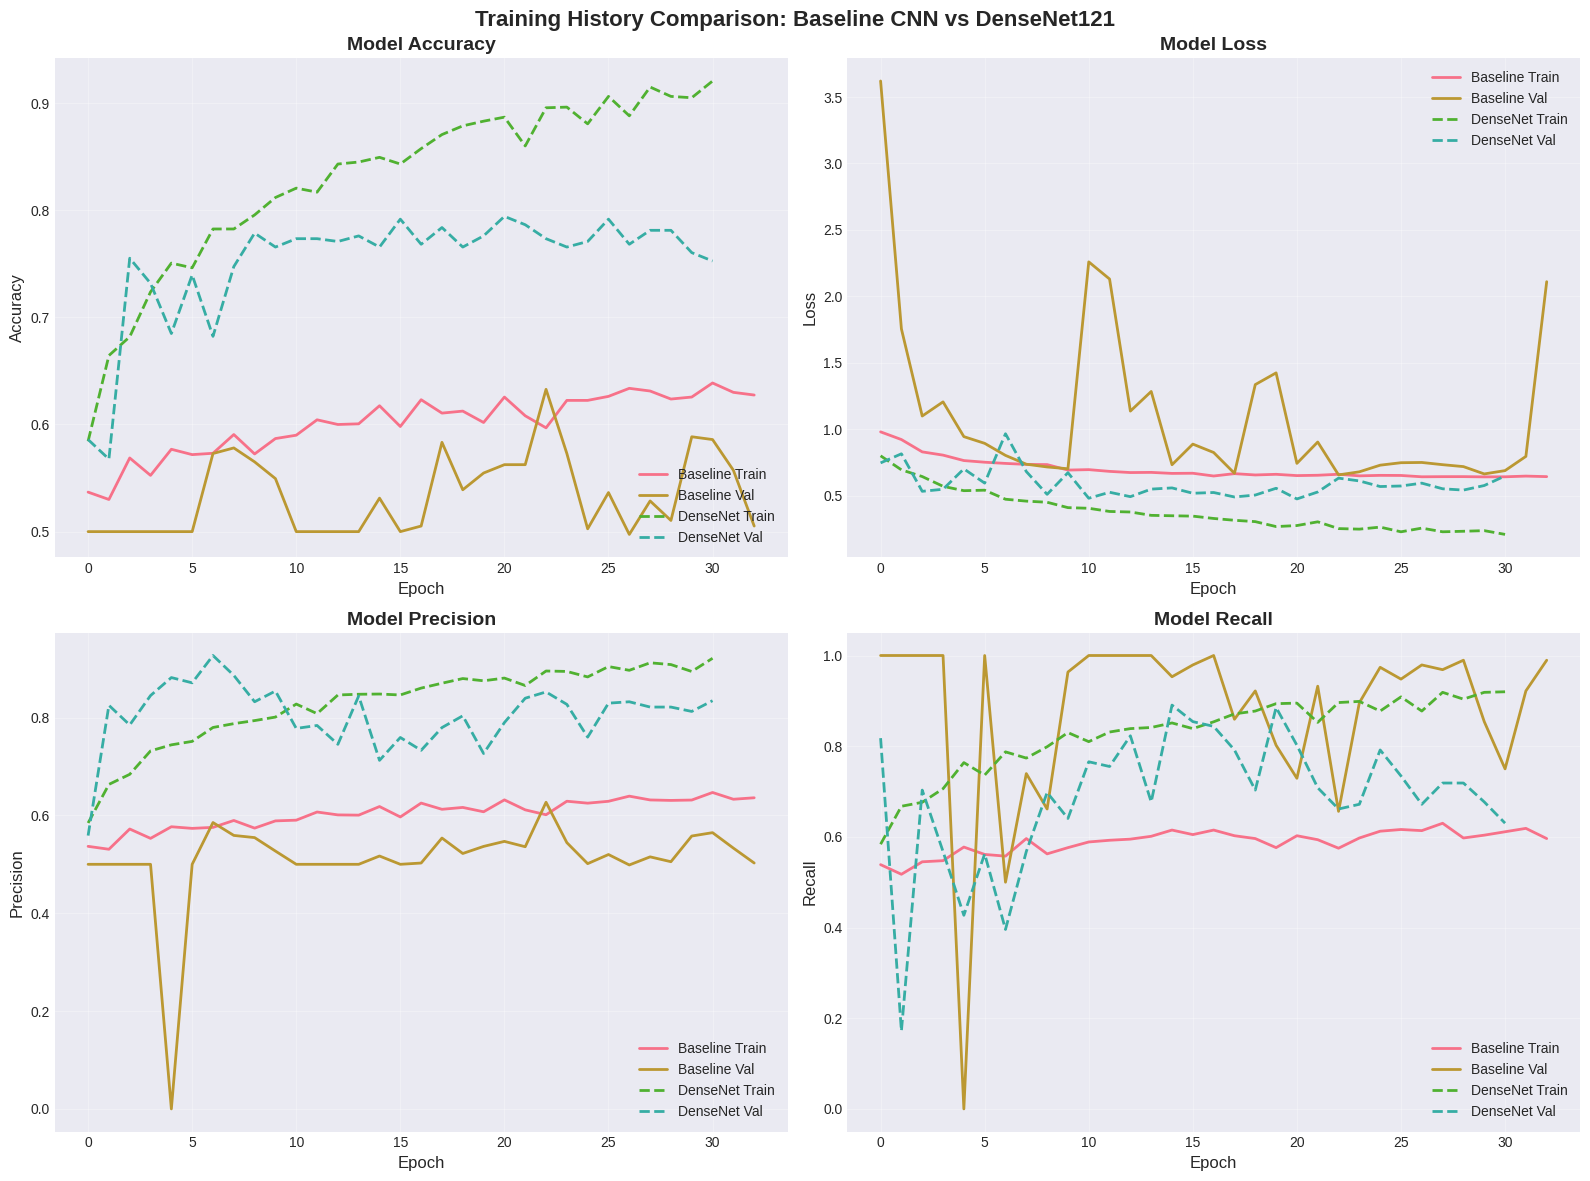

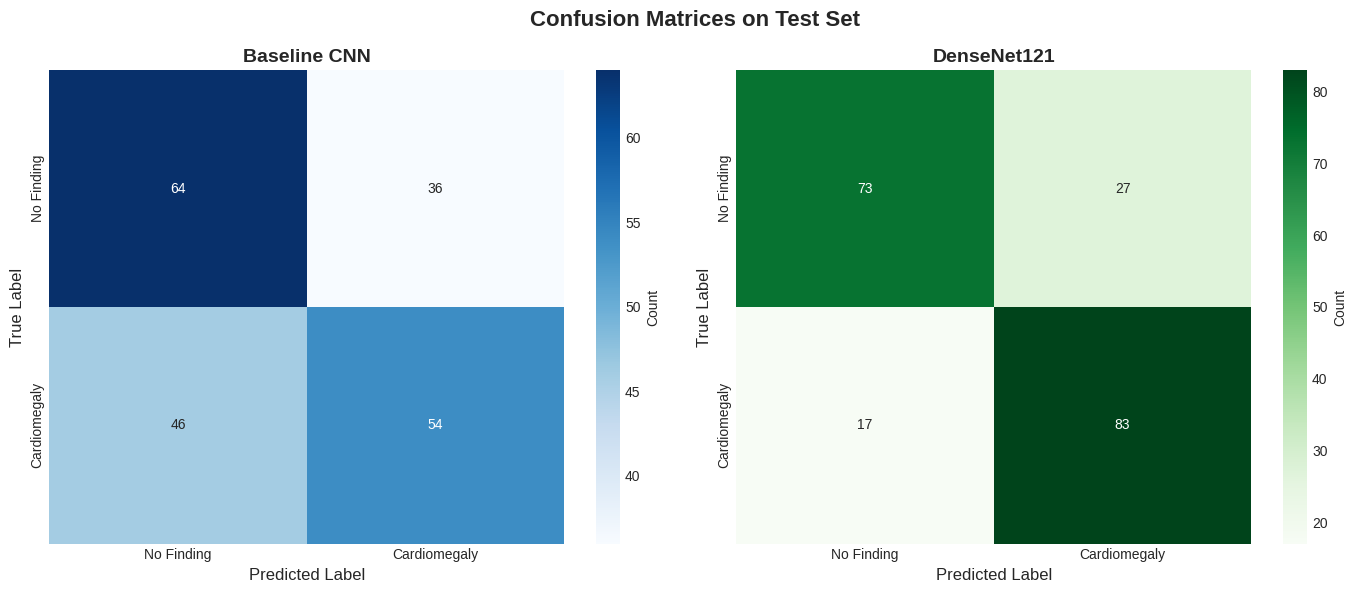

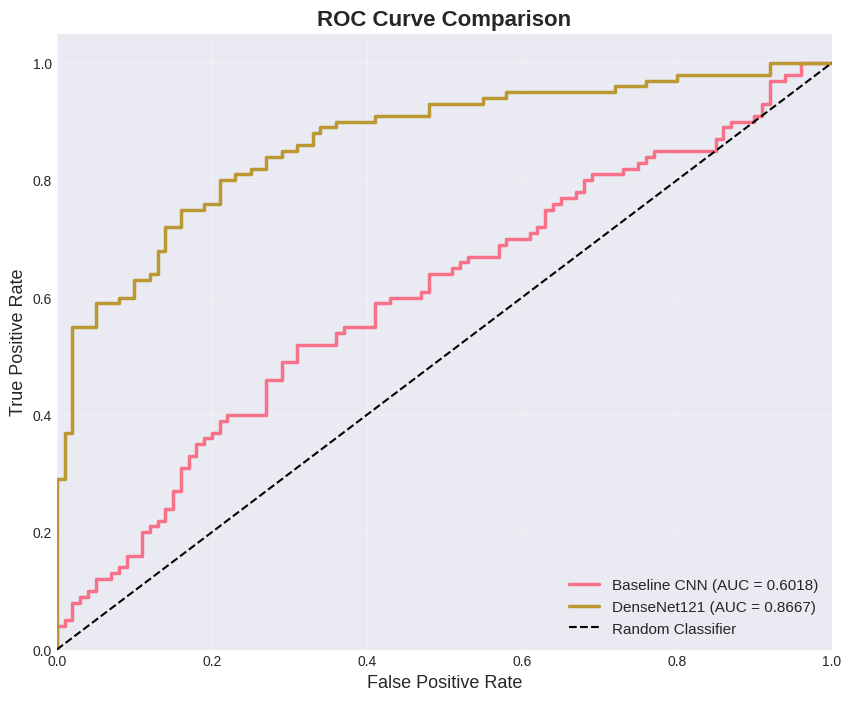

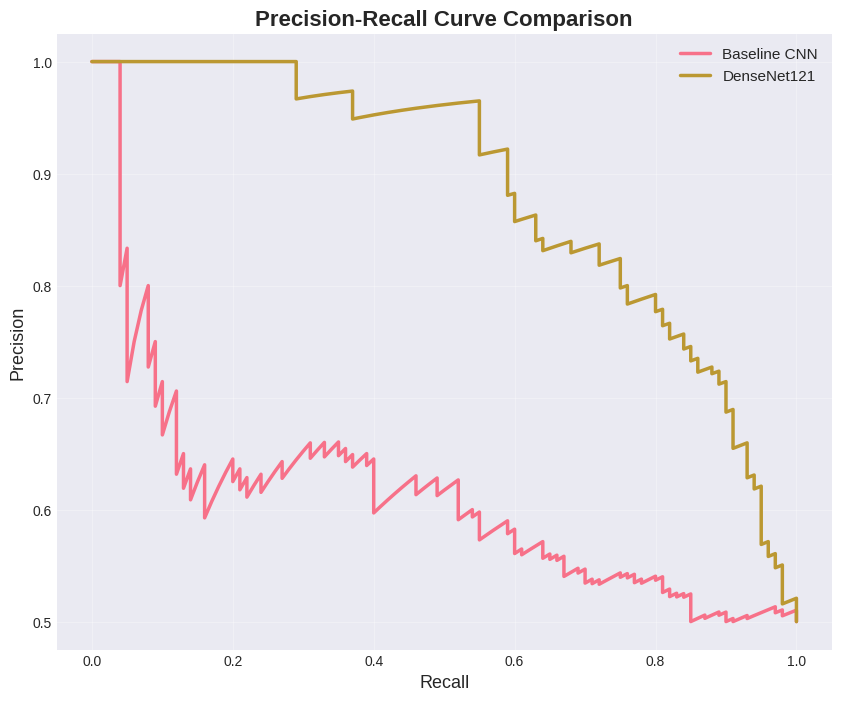

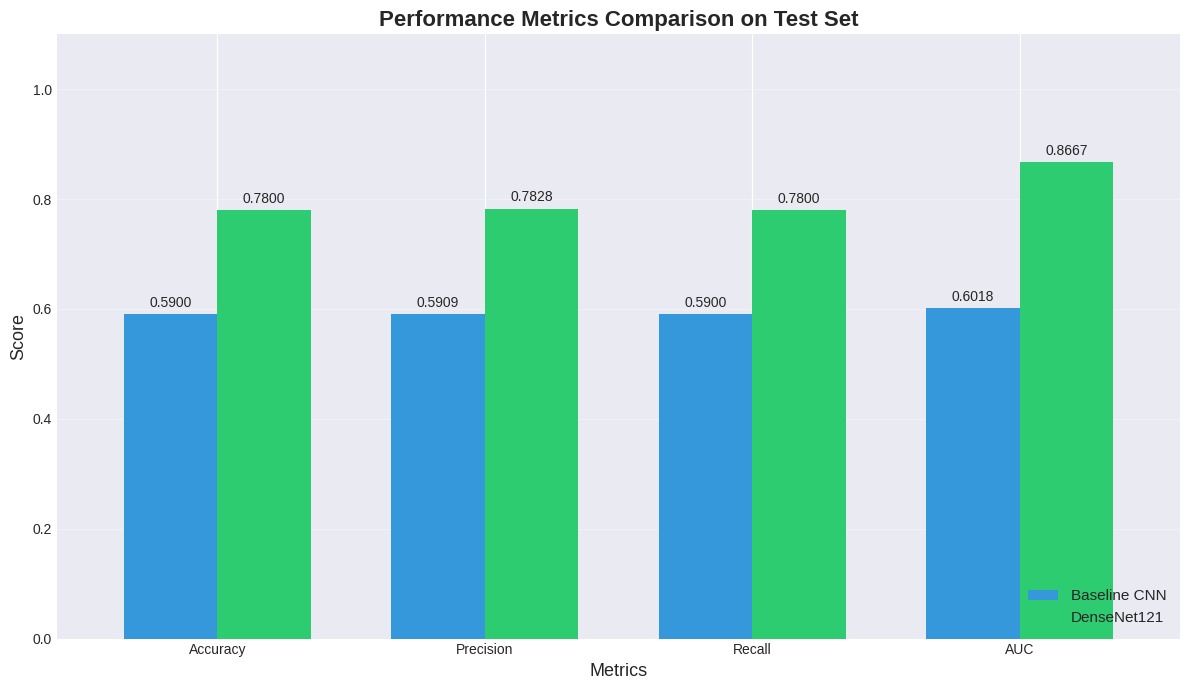

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


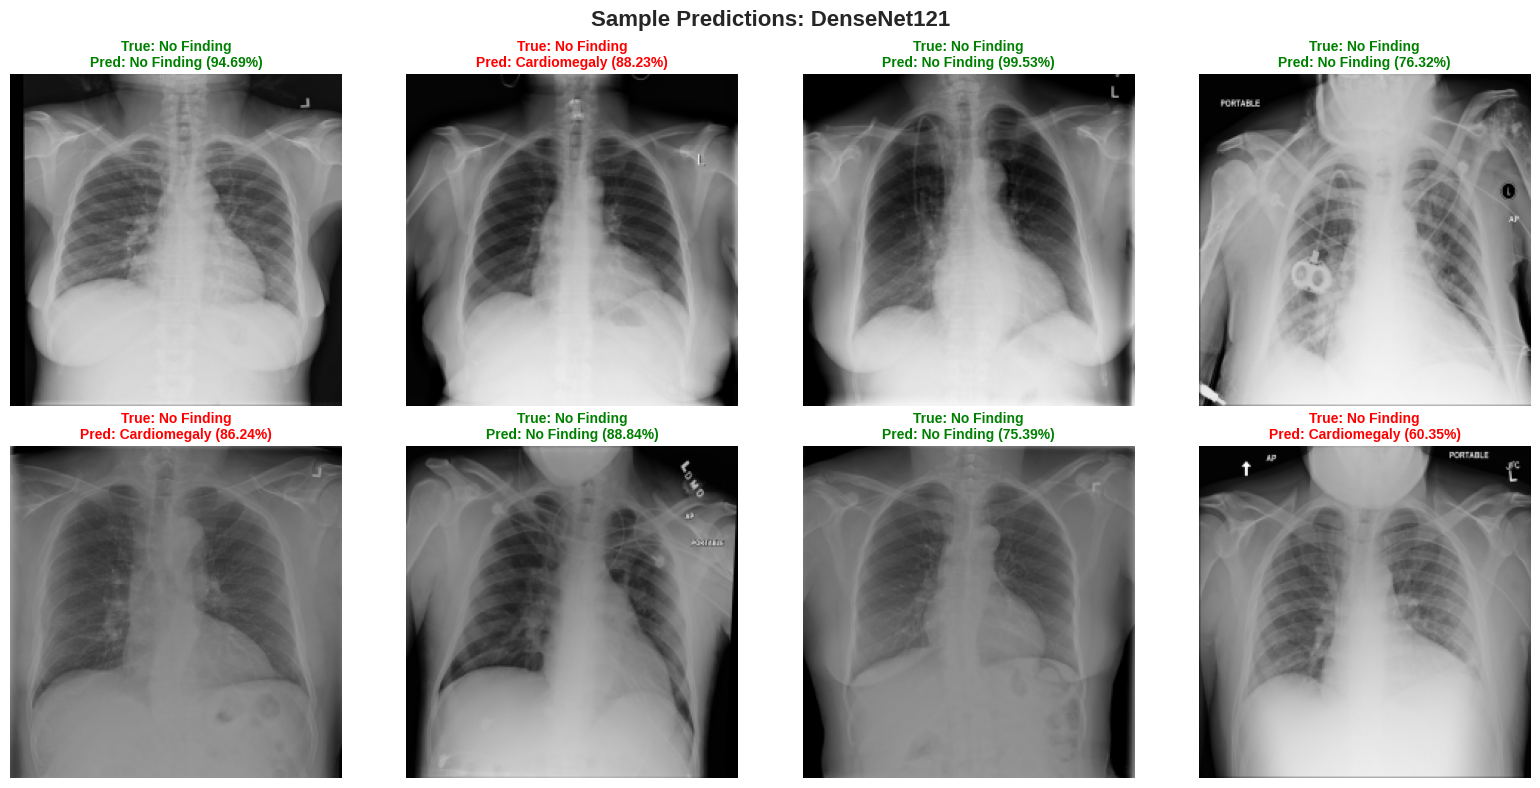

In [13]:
print("GENERATING VISUALIZATIONS")

# 1. Training History Comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Training History Comparison: Baseline CNN vs DenseNet121',
             fontsize=16, fontweight='bold')

# Accuracy
axes[0, 0].plot(baseline_history.history['accuracy'], label='Baseline Train', linewidth=2)
axes[0, 0].plot(baseline_history.history['val_accuracy'], label='Baseline Val', linewidth=2)
axes[0, 0].plot(densenet_history.history['accuracy'], label='DenseNet Train',
                linewidth=2, linestyle='--')
axes[0, 0].plot(densenet_history.history['val_accuracy'], label='DenseNet Val',
                linewidth=2, linestyle='--')
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Accuracy', fontsize=12)
axes[0, 0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0, 0].legend(loc='lower right')
axes[0, 0].grid(True, alpha=0.3)

# Loss
axes[0, 1].plot(baseline_history.history['loss'], label='Baseline Train', linewidth=2)
axes[0, 1].plot(baseline_history.history['val_loss'], label='Baseline Val', linewidth=2)
axes[0, 1].plot(densenet_history.history['loss'], label='DenseNet Train',
                linewidth=2, linestyle='--')
axes[0, 1].plot(densenet_history.history['val_loss'], label='DenseNet Val',
                linewidth=2, linestyle='--')
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Loss', fontsize=12)
axes[0, 1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0, 1].legend(loc='upper right')
axes[0, 1].grid(True, alpha=0.3)

# Precision - Corrected keys for DenseNet
axes[1, 0].plot(baseline_history.history['precision'], label='Baseline Train', linewidth=2)
axes[1, 0].plot(baseline_history.history['val_precision'], label='Baseline Val', linewidth=2)
axes[1, 0].plot(densenet_history.history['precision_1'], label='DenseNet Train',
                linewidth=2, linestyle='--')
axes[1, 0].plot(densenet_history.history['val_precision_1'], label='DenseNet Val',
                linewidth=2, linestyle='--')
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Precision', fontsize=12)
axes[1, 0].set_title('Model Precision', fontsize=14, fontweight='bold')
axes[1, 0].legend(loc='lower right')
axes[1, 0].grid(True, alpha=0.3)

# Recall - Corrected keys for DenseNet
axes[1, 1].plot(baseline_history.history['recall'], label='Baseline Train', linewidth=2)
axes[1, 1].plot(baseline_history.history['val_recall'], label='Baseline Val', linewidth=2)
axes[1, 1].plot(densenet_history.history['recall_1'], label='DenseNet Train',
                linewidth=2, linestyle='--')
axes[1, 1].plot(densenet_history.history['val_recall_1'], label='DenseNet Val',
                linewidth=2, linestyle='--')
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Recall', fontsize=12)
axes[1, 1].set_title('Model Recall', fontsize=14, fontweight='bold')
axes[1, 1].legend(loc='lower right')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Confusion Matrices on Test Set', fontsize=16, fontweight='bold')

# Baseline CNN
sns.heatmap(baseline_results['cm'], annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Finding', 'Cardiomegaly'],
            yticklabels=['No Finding', 'Cardiomegaly'], ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('Baseline CNN', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

# DenseNet121
sns.heatmap(densenet_results['cm'], annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Finding', 'Cardiomegaly'],
            yticklabels=['No Finding', 'Cardiomegaly'], ax=axes[1], cbar_kws={'label': 'Count'})
axes[1].set_title('DenseNet121', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. ROC Curves
plt.figure(figsize=(10, 8))
plt.plot(baseline_results['fpr'], baseline_results['tpr'],
         label=f"Baseline CNN (AUC = {baseline_results['roc_auc']:.4f})",
         linewidth=2.5)
plt.plot(densenet_results['fpr'], densenet_results['tpr'],
         label=f"DenseNet121 (AUC = {densenet_results['roc_auc']:.4f})",
         linewidth=2.5)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curve Comparison', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Precision-Recall Curves - Corrected keys for curve data
plt.figure(figsize=(10, 8))
plt.plot(baseline_results['recall_curve'], baseline_results['precision_curve'],
         label='Baseline CNN', linewidth=2.5)
plt.plot(densenet_results['recall_curve'], densenet_results['precision_curve'],
         label='DenseNet121', linewidth=2.5)
plt.xlabel('Recall', fontsize=13)
plt.ylabel('Precision', fontsize=13)
plt.title('Precision-Recall Curve Comparison', fontsize=16, fontweight='bold')
plt.legend(loc="upper right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.savefig('precision_recall_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. Performance Metrics Comparison Bar Chart
metrics_comparison = pd.DataFrame({
    'Baseline CNN': [
        baseline_results['metrics']['accuracy'],
        baseline_results['metrics']['precision'],
        baseline_results['metrics']['recall'],
        baseline_results['metrics']['auc']
    ],
    'DenseNet121': [
        densenet_results['metrics']['accuracy'],
        densenet_results['metrics']['precision'],
        densenet_results['metrics']['recall'],
        densenet_results['metrics']['auc']
    ]
}, index=['Accuracy', 'Precision', 'Recall', 'AUC'])

fig, ax = plt.subplots(figsize=(12, 7))
metrics_comparison.plot(kind='bar', ax=ax, width=0.7, color=['#3498db', '#2ecc71'])
ax.set_title('Performance Metrics Comparison on Test Set',
             fontsize=16, fontweight='bold')
ax.set_ylabel('Score', fontsize=13)
ax.set_xlabel('Metrics', fontsize=13)
ax.set_ylim([0, 1.1])
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=0)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3, fontsize=10)

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 6. Sample Predictions Visualization
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Sample Predictions: DenseNet121', fontsize=16, fontweight='bold')

test_generator.reset()
x_batch, y_batch = next(test_generator)
predictions = densenet_model.predict(x_batch[:8])

for idx in range(8):
    row = idx // 4
    col = idx % 4

    axes[row, col].imshow(x_batch[idx])
    true_label = 'Cardiomegaly' if y_batch[idx] == 1 else 'No Finding'
    pred_label = 'Cardiomegaly' if predictions[idx] > 0.5 else 'No Finding'
    confidence = predictions[idx][0] if predictions[idx] > 0.5 else 1 - predictions[idx][0]

    color = 'green' if true_label == pred_label else 'red'
    axes[row, col].set_title(f'True: {true_label}\nPred: {pred_label} ({confidence:.2%})',
                            color=color, fontsize=10, fontweight='bold')
    axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

#### SECTION 8: FINAL SUMMARY


In [14]:
print("FINAL SUMMARY")

summary_df = pd.DataFrame({
    'Model': ['Baseline CNN', 'DenseNet121'],
    'Accuracy': [
        baseline_results['metrics']['accuracy'],
        densenet_results['metrics']['accuracy']
    ],
    'Precision': [
        baseline_results['metrics']['precision'],
        densenet_results['metrics']['precision']
    ],
    'Recall': [
        baseline_results['metrics']['recall'],
        densenet_results['metrics']['recall']
    ],
    'AUC': [
        baseline_results['metrics']['auc'],
        densenet_results['metrics']['auc']
    ],
    'F1-Score': [
        2 * (baseline_results['metrics']['precision'] * baseline_results['metrics']['recall']) /
        (baseline_results['metrics']['precision'] + baseline_results['metrics']['recall']),
        2 * (densenet_results['metrics']['precision'] * densenet_results['metrics']['recall']) /
        (densenet_results['metrics']['precision'] + densenet_results['metrics']['recall'])
    ]
})

print("\n Model Comparison Table:")
print(summary_df.to_string(index=False))

FINAL SUMMARY

 Model Comparison Table:
       Model  Accuracy  Precision  Recall    AUC  F1-Score
Baseline CNN      0.59   0.590909    0.59 0.6018  0.590454
 DenseNet121      0.78   0.782828    0.78 0.8667  0.781412


#### Save summary


In [15]:
summary_df.to_csv('model_comparison_summary.csv', index=False)

print("\n ALL TASKS COMPLETED SUCCESSFULLY!")
print("\n Generated Files:")
print("  • training_history_comparison.png")
print("  • confusion_matrices.png")
print("  • roc_curves.png")
print("  • precision_recall_curves.png")
print("  • metrics_comparison.png")
print("  • sample_predictions.png")
print("  • model_comparison_summary.csv")
print("  • baseline_best.h5")
print("  • densenet_best.h5")


 ALL TASKS COMPLETED SUCCESSFULLY!

 Generated Files:
  • training_history_comparison.png
  • confusion_matrices.png
  • roc_curves.png
  • precision_recall_curves.png
  • metrics_comparison.png
  • sample_predictions.png
  • model_comparison_summary.csv
  • baseline_best.h5
  • densenet_best.h5
